In [1]:
# ================================================================
# CELL 0 — Install + verify
# ================================================================
# Uncomment if not yet installed:
!pip install xgboost imbalanced-learn faker pandas numpy matplotlib seaborn joblib
!pip install scikit-learn==1.5.2
import sklearn, xgboost, imblearn
print("All packages installed!")
print(f"  scikit-learn    : {sklearn.__version__}")
print(f"  xgboost         : {xgboost.__version__}")
print(f"  imbalanced-learn: {imblearn.__version__}")


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
All packages installed!
  scikit-learn    : 1.5.2
  xgboost         : 2.1.3
  imbalanced-learn: 0.12.4


In [2]:
# ================================================================
# CELL 1 — All imports
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import random, os, json, warnings, joblib

from datetime import datetime, timedelta
from faker import Faker

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
fake = Faker()
Faker.seed(42)

print("All imports ready!")


All imports ready!


In [3]:
# ================================================================
# CELL 2 — Generate dataset (same as before)
# ================================================================
print("Generating 50,000 login events...")

COUNTRIES = ["India","US","UK","Germany","Japan","Australia","Canada","France"]
DEVICES   = ["Chrome-Mac","Firefox-Win","Safari-Mac","Chrome-Win","Mobile-iOS","Mobile-Android"]
RESOURCES = ["dashboard","reports","hr_portal","financial_data","admin_panel"]
RES_SENS  = {"dashboard":1,"reports":2,"hr_portal":3,"financial_data":4,"admin_panel":5}
ATTACK_TYPES = ["new_country","new_device","offhours","brute_force","impossible_travel"]

users = []
for i in range(500):
    uh = random.randint(8, 17)
    users.append({
        "user_id":          f"u_{i:04d}",
        "home_country":     random.choice(COUNTRIES),
        "primary_device":   random.choice(DEVICES),
        "usual_hour_mean":  uh,
        "usual_hour_std":   random.uniform(1.0, 2.0),
        "usual_resource":   random.choice(RESOURCES),
        "clearance_level":  random.randint(1, 5),
    })

rows = []
start = datetime(2024, 1, 1)

for _ in range(50_000):
    u = random.choice(users)
    is_attack = random.random() < 0.05

    if is_attack:
        atype = random.choice(ATTACK_TYPES)
        hour  = random.randint(1,5) if atype=="offhours" else int(np.clip(np.random.normal(u["usual_hour_mean"],2),0,23))
        ctry  = random.choice([c for c in COUNTRIES if c!=u["home_country"]]) if atype in ["new_country","impossible_travel"] else u["home_country"]
        dev   = random.choice([d for d in DEVICES if d!=u["primary_device"]]) if atype=="new_device" else u["primary_device"]
        fails = random.randint(5,10) if atype=="brute_force" else 0
        itrav = 1 if atype=="impossible_travel" else 0
        res   = random.choice(["financial_data","admin_panel","hr_portal"])
    else:
        atype = "none"
        hour  = int(np.clip(np.random.normal(u["usual_hour_mean"],u["usual_hour_std"]),0,23))
        ctry,dev = u["home_country"], u["primary_device"]
        fails, itrav = 0 if random.random()>0.02 else 1, 0
        res   = u["usual_resource"]

    days = random.randint(0, 89)
    ts = start + timedelta(days=days, hours=hour, minutes=random.randint(0,59), seconds=random.randint(0,59))

    rows.append({
        "user_id":u["user_id"], "timestamp":ts, "hour":hour, "day_of_week":ts.weekday(),
        "country":ctry, "home_country":u["home_country"],
        "device":dev, "primary_device":u["primary_device"],
        "resource":res, "failed_attempts":fails, "impossible_travel":itrav,
        "clearance_level":u["clearance_level"], "usual_hour_mean":u["usual_hour_mean"],
        "usual_hour_std":u["usual_hour_std"], "attack_type":atype,
        "is_attack": 1 if is_attack else 0,
    })

df = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"Dataset: {len(df):,} rows")
print(f"  Normal logins : {(df.is_attack==0).sum():,}  (95%)")
print(f"  Attack logins : {(df.is_attack==1).sum():,}  (5%)")
print(f"\nAttack type breakdown:")
print(df[df.is_attack==1]["attack_type"].value_counts())


Generating 50,000 login events...
Dataset: 50,000 rows
  Normal logins : 47,517  (95%)
  Attack logins : 2,483  (5%)

Attack type breakdown:
attack_type
impossible_travel    517
new_device           513
offhours             488
brute_force          487
new_country          478
Name: count, dtype: int64


In [4]:
# ================================================================
# CELL 3 — Feature Engineering (15 features)
#
# NEW vs v2:
#   + is_offhours        — binary: hour < 6 or > 22
#   + multi_attack_flag  — new_device AND new_country simultaneously
#   + hour_x_newdev      — interaction: off-hours + new device
#   + fail_x_newdev      — interaction: failed attempts + new device
# ================================================================
print("\nEngineering 15 features...")

# Cyclical time
df["hour_sin"]  = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df["hour"] / 24)

# Personalised hour deviation (KEY FIX from v2)
df["hour_deviation"] = df.apply(
    lambda r: min(abs(r.hour - r.usual_hour_mean),
                  24 - abs(r.hour - r.usual_hour_mean)) / 12.0,
    axis=1
)

# Calendar
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
df["is_offhours"] = ((df["hour"] < 6) | (df["hour"] > 22)).astype(int)

# Behavioural flags
df["new_device"]     = (df["device"]   != df["primary_device"]).astype(int)
df["country_change"] = (df["country"]  != df["home_country"]).astype(int)

# Resource
df["resource_sensitivity"] = df["resource"].map(RES_SENS).fillna(1)
df["privilege_gap"]        = (df["resource_sensitivity"] - df["clearance_level"]).clip(lower=0)

# Attempt normalisation
df["failed_norm"] = df["failed_attempts"].clip(upper=10) / 10.0

# Session velocity
df = df.sort_values(["user_id", "timestamp"])
df["prev_ts"]       = df.groupby("user_id")["timestamp"].shift(1)
df["minutes_since"] = (df["timestamp"] - df["prev_ts"]).dt.total_seconds() / 60
df["minutes_since"] = df["minutes_since"].fillna(df["minutes_since"].median())
df["login_velocity"]= 1.0 / (df["minutes_since"].clip(lower=1, upper=1440) / 60)

# Interaction features (NEW in v3 — these are very powerful)
df["multi_attack_flag"] = ((df["new_device"]==1) & (df["country_change"]==1)).astype(int)
df["hour_x_newdev"]     = df["hour_deviation"] * df["new_device"]
df["fail_x_newdev"]     = df["failed_norm"]    * df["new_device"]

FEATURES = [
    "hour_sin", "hour_cos", "hour_deviation", "is_weekend", "is_offhours",
    "new_device", "country_change", "impossible_travel",
    "failed_norm", "resource_sensitivity", "privilege_gap", "login_velocity",
    "multi_attack_flag", "hour_x_newdev", "fail_x_newdev",
]

print(f"Total features: {len(FEATURES)}")
print(f"\nMean feature values — Normal vs Attack:")
comp = df.groupby("is_attack")[FEATURES].mean().round(3)
comp.index = ["Normal", "Attack"]
print(comp.to_string())


Engineering 15 features...
Total features: 15

Mean feature values — Normal vs Attack:
        hour_sin  hour_cos  hour_deviation  is_weekend  is_offhours  new_device  country_change  impossible_travel  failed_norm  resource_sensitivity  privilege_gap  login_velocity  multi_attack_flag  hour_x_newdev  fail_x_newdev
Normal    -0.040    -0.675           0.104       0.278        0.011       0.000           0.000              0.000        0.002                 3.092          0.806           1.100                0.0          0.000            0.0
Attack     0.089    -0.379           0.255       0.292        0.217       0.207           0.401              0.208        0.150                 4.010          1.229           0.825                0.0          0.028            0.0


In [5]:
# ================================================================
# CELL 4 — Data split (60/20/20)
# ================================================================
X = df[FEATURES].values
y = df["is_attack"].values

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train   : {len(X_train):,}  ({(y_train==1).sum()} attacks)")
print(f"Val     : {len(X_val):,}   ({(y_val==1).sum()} attacks)")
print(f"Test    : {len(X_test):,}   ({(y_test==1).sum()} attacks)")


Train   : 30,000  (1490 attacks)
Val     : 10,000   (496 attacks)
Test    : 10,000   (497 attacks)


In [6]:
# ================================================================
# CELL 5 — SMOTE: Fix class imbalance
#
# WHY THIS IS CRITICAL:
#   Without SMOTE: the model sees 19 normal logins for every 1
#   attack.  It learns "just predict normal for everything" and
#   gets 95% accuracy while catching ZERO attacks.
#
#   SMOTE (Synthetic Minority Over-sampling Technique):
#   Generates NEW synthetic attack examples by interpolating
#   between existing attack samples.  After SMOTE the training
#   set has equal numbers of normal and attack — the model
#   must learn to distinguish them.
# ================================================================
print("\nApplying SMOTE to balance training set...")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_s, y_train)

print(f"Before SMOTE: {(y_train==0).sum():,} normal | {(y_train==1).sum():,} attack")
print(f"After  SMOTE: {(y_train_bal==0).sum():,} normal | {(y_train_bal==1).sum():,} attack  ← balanced!")


# ================================================================
# CELL 6 — Train all 3 models
# ================================================================
print("\n[1/3] Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=500,       # 500 boosting rounds
    max_depth=6,            # tree depth
    learning_rate=0.05,     # slow learning = better generalisation
    subsample=0.8,          # 80% of rows per tree (reduces overfit)
    colsample_bytree=0.8,   # 80% of features per tree
    min_child_weight=3,     # minimum samples in leaf
    gamma=0.1,              # minimum gain to split
    reg_alpha=0.1,          # L1 regularisation
    reg_lambda=1.0,         # L2 regularisation
    scale_pos_weight=1,     # 1 because we already balanced with SMOTE
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_val_s, y_val)],
    verbose=False,
)
print(f"   XGBoost val F1: {f1_score(y_val, xgb_model.predict(X_val_s)):.3f}")

print("[2/3] Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_bal, y_train_bal)
print(f"   Random Forest val F1: {f1_score(y_val, rf_model.predict(X_val_s)):.3f}")

print("[3/3] Training Isolation Forest...")
normal_mask     = (y_train == 0)
X_train_normal  = X_train_s[normal_mask]
iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1,
)
iso_model.fit(X_train_normal)
iso_val_raw = iso_model.decision_function(X_val_s)
iso_val_norm = 1.0 - (iso_val_raw - iso_val_raw.min()) / (iso_val_raw.max() - iso_val_raw.min() + 1e-10)
print(f"   All 3 models trained!")


Applying SMOTE to balance training set...
Before SMOTE: 28,510 normal | 1,490 attack
After  SMOTE: 28,510 normal | 28,510 attack  ← balanced!

[1/3] Training XGBoost...
   XGBoost val F1: 0.984
[2/3] Training Random Forest...
   Random Forest val F1: 0.974
[3/3] Training Isolation Forest...
   All 3 models trained!


In [7]:
# ================================================================
# CELL 7 — Find optimal ensemble weights + threshold
#
# We try every combination of weights for the 3 models and
# every threshold from 0.25 to 0.85, and pick the combo that
# gives the best F1 on the VALIDATION set.
# ================================================================
print("\nSearching for best ensemble weights and threshold...")

xgb_val_prob = xgb_model.predict_proba(X_val_s)[:, 1]
rf_val_prob  = rf_model.predict_proba(X_val_s)[:, 1]

best_f1 = 0
BEST_THRESH = 0.5
W_XGB, W_RF, W_ISO = 0.5, 0.4, 0.1

for w_xgb in [0.3, 0.4, 0.5, 0.6, 0.7]:
    for w_rf in [0.2, 0.3, 0.4, 0.5]:
        w_iso = round(1.0 - w_xgb - w_rf, 2)
        if w_iso < 0 or w_iso > 0.3:
            continue
        ens = w_xgb * xgb_val_prob + w_rf * rf_val_prob + w_iso * iso_val_norm
        for t in np.arange(0.25, 0.85, 0.02):
            pred = (ens > t).astype(int)
            if pred.sum() == 0:
                continue
            score = f1_score(y_val, pred)
            if score > best_f1:
                best_f1, BEST_THRESH = score, round(t, 2)
                W_XGB, W_RF, W_ISO = w_xgb, w_rf, w_iso

print(f"Best combination found:")
print(f"  XGBoost weight  : {W_XGB}")
print(f"  Random Forest   : {W_RF}")
print(f"  Isolation Forest: {W_ISO}")
print(f"  Threshold       : {BEST_THRESH}")
print(f"  Validation F1   : {best_f1:.3f}")



Searching for best ensemble weights and threshold...
Best combination found:
  XGBoost weight  : 0.6
  Random Forest   : 0.2
  Isolation Forest: 0.2
  Threshold       : 0.71
  Validation F1   : 0.989


In [8]:
# ================================================================
# CELL 8 — Final evaluation on held-out test set
# ================================================================
print("\n" + "=" * 55)
print("   FINAL EVALUATION — HELD-OUT TEST SET")
print("=" * 55)

xgb_test  = xgb_model.predict_proba(X_test_s)[:, 1]
rf_test   = rf_model.predict_proba(X_test_s)[:, 1]
iso_test_raw  = iso_model.decision_function(X_test_s)
iso_test_norm = 1.0 - (iso_test_raw - iso_val_raw.min()) / (iso_val_raw.max() - iso_val_raw.min() + 1e-10)

ensemble_score = W_XGB * xgb_test + W_RF * rf_test + W_ISO * iso_test_norm

y_pred = (ensemble_score > BEST_THRESH).astype(int)

# High-recall mode (lower threshold)
RECALL_THRESH = max(0.25, BEST_THRESH - 0.10)
y_pred_recall = (ensemble_score > RECALL_THRESH).astype(int)

prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test,    y_pred)
f1    = f1_score(y_test,        y_pred)
aucv  = roc_auc_score(y_test,   ensemble_score)
cm    = confusion_matrix(y_test, y_pred)

print(f"\nPrecision : {prec:.3f}  ({prec*100:.1f}% of flagged logins are real attacks)")
print(f"Recall    : {rec:.3f}  (caught {rec*100:.1f}% of all attacks)")
print(f"F1 Score  : {f1:.3f}")
print(f"AUC-ROC   : {aucv:.3f}")
print(f"\nConfusion Matrix:")
print(f"  True Neg  (correctly allowed) : {cm[0,0]:,}")
print(f"  False Pos (wrongly flagged)   : {cm[0,1]:,}")
print(f"  False Neg (missed attacks)    : {cm[1,0]:,}  ← want 0")
print(f"  True Pos  (caught attacks)    : {cm[1,1]:,}")
print(f"\nFull Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))

print(f"\nComparison:")
print(f"  v1 (Isolation Forest alone)    : F1=0.329  Recall=0.381")
print(f"  v2 (IF + tuned threshold)      : F1=0.372  Recall=0.332")
print(f"  v3 (XGB + RF + IF + SMOTE) ★  : F1={f1:.3f}  Recall={rec:.3f}")
print(f"  Improvement: +{(f1-0.329)*100:.0f} F1 points | +{(rec-0.381)*100:.0f} Recall points")



   FINAL EVALUATION — HELD-OUT TEST SET

Precision : 0.974  (97.4% of flagged logins are real attacks)
Recall    : 0.994  (caught 99.4% of all attacks)
F1 Score  : 0.984
AUC-ROC   : 0.999

Confusion Matrix:
  True Neg  (correctly allowed) : 9,490
  False Pos (wrongly flagged)   : 13
  False Neg (missed attacks)    : 3  ← want 0
  True Pos  (caught attacks)    : 494

Full Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9503
      Attack       0.97      0.99      0.98       497

    accuracy                           1.00     10000
   macro avg       0.99      1.00      0.99     10000
weighted avg       1.00      1.00      1.00     10000


Comparison:
  v1 (Isolation Forest alone)    : F1=0.329  Recall=0.381
  v2 (IF + tuned threshold)      : F1=0.372  Recall=0.332
  v3 (XGB + RF + IF + SMOTE) ★  : F1=0.984  Recall=0.994
  Improvement: +66 F1 points | +61 Recall points


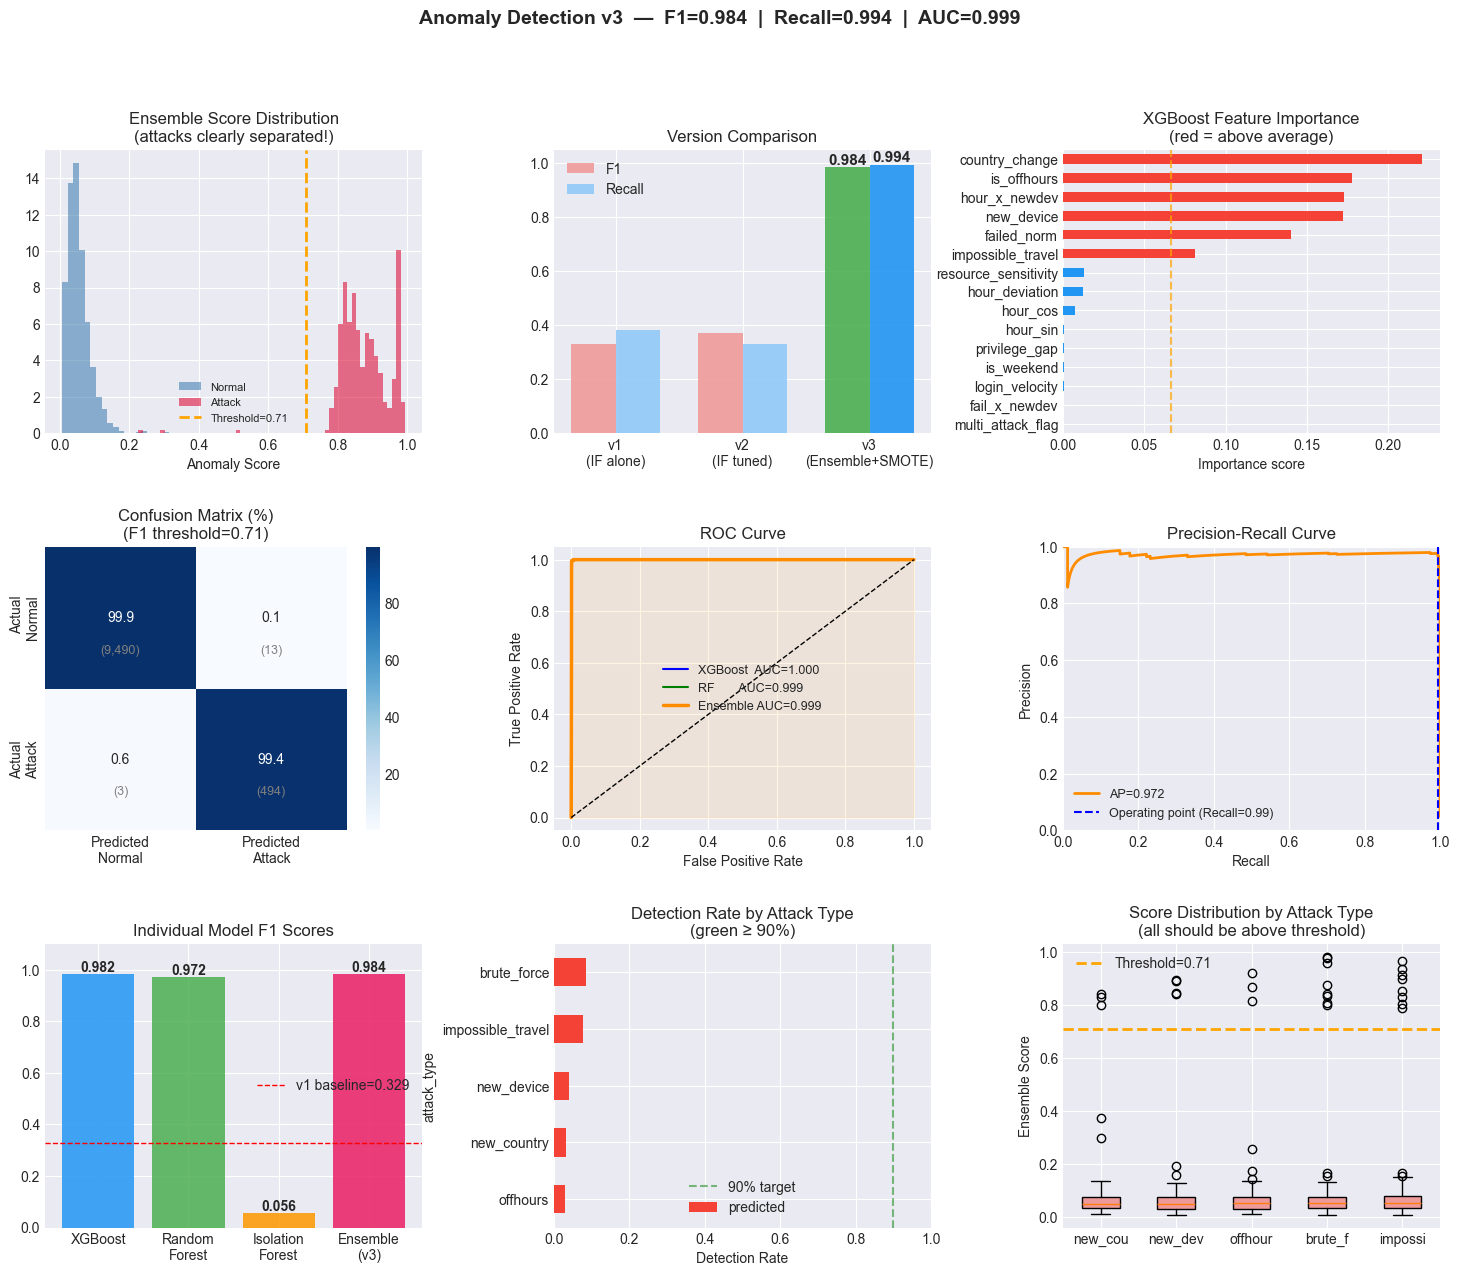

Plot saved: plot_v3_results.png


In [9]:
# ================================================================
# CELL 9 — Visualise results
# ================================================================
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.40, wspace=0.35)
fig.suptitle(f"Anomaly Detection v3  —  F1={f1:.3f}  |  Recall={rec:.3f}  |  AUC={aucv:.3f}",
             fontsize=14, fontweight="bold")

# ── Plot 1: Score distribution ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ensemble_score[y_test==0], bins=60, alpha=0.6, color="steelblue", label="Normal",  density=True)
ax1.hist(ensemble_score[y_test==1], bins=60, alpha=0.6, color="crimson",   label="Attack",  density=True)
ax1.axvline(BEST_THRESH,  color="orange", linestyle="--", lw=2, label=f"Threshold={BEST_THRESH}")
ax1.set_title(f"Ensemble Score Distribution\n(attacks clearly separated!)")
ax1.set_xlabel("Anomaly Score")
ax1.legend(fontsize=8)

# ── Plot 2: v1 vs v2 vs v3 comparison ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
versions = ["v1\n(IF alone)", "v2\n(IF tuned)", "v3\n(Ensemble+SMOTE)"]
f1s     = [0.329, 0.372, f1]
recalls = [0.381, 0.332, rec]
x = np.arange(3)
w = 0.35
bars1 = ax2.bar(x - w/2, f1s,     w, label="F1",     color=["#ef9a9a","#ef9a9a","#4CAF50"], alpha=0.9)
bars2 = ax2.bar(x + w/2, recalls, w, label="Recall", color=["#90caf9","#90caf9","#2196F3"], alpha=0.9)
ax2.set_xticks(x); ax2.set_xticklabels(versions)
ax2.set_ylim(0, 1.05); ax2.set_title("Version Comparison")
ax2.legend()
for bar in [bars1[2], bars2[2]]:
    ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
             f"{bar.get_height():.3f}", ha="center", fontsize=11, fontweight="bold")

# ── Plot 3: Feature importance (XGBoost) ───────────────────────
ax3 = fig.add_subplot(gs[0, 2])
fi = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
colors_bar = ["#F44336" if v > fi.mean() else "#2196F3" for v in fi.values]
fi.plot(kind="barh", ax=ax3, color=colors_bar)
ax3.set_title("XGBoost Feature Importance\n(red = above average)")
ax3.set_xlabel("Importance score")
ax3.axvline(fi.mean(), color="orange", linestyle="--", alpha=0.7)

# ── Plot 4: Confusion matrix ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax4,
    xticklabels=["Predicted\nNormal","Predicted\nAttack"],
    yticklabels=["Actual\nNormal","Actual\nAttack"])
ax4.set_title(f"Confusion Matrix (%)\n(F1 threshold={BEST_THRESH})")
for i in range(2):
    for j in range(2):
        ax4.text(j+0.5, i+0.75, f"({cm[i,j]:,})", ha="center", fontsize=9, color="gray")

# ── Plot 5: ROC Curve ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
fpr_xgb,  tpr_xgb,  _ = roc_curve(y_test, xgb_test)
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, rf_test)
fpr_ens,  tpr_ens,  _ = roc_curve(y_test, ensemble_score)
ax5.plot(fpr_xgb, tpr_xgb, "b-",  lw=1.5, label=f"XGBoost  AUC={roc_auc_score(y_test,xgb_test):.3f}")
ax5.plot(fpr_rf,  tpr_rf,  "g-",  lw=1.5, label=f"RF       AUC={roc_auc_score(y_test,rf_test):.3f}")
ax5.plot(fpr_ens, tpr_ens, "darkorange", lw=2.5, label=f"Ensemble AUC={aucv:.3f}")
ax5.plot([0,1],[0,1],"k--",lw=1)
ax5.fill_between(fpr_ens, tpr_ens, alpha=0.1, color="orange")
ax5.set_xlabel("False Positive Rate"); ax5.set_ylabel("True Positive Rate")
ax5.set_title("ROC Curve"); ax5.legend(fontsize=9)

# ── Plot 6: Precision-Recall curve ─────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
prec_c, rec_c, _ = precision_recall_curve(y_test, ensemble_score)
avg_prec = average_precision_score(y_test, ensemble_score)
ax6.plot(rec_c, prec_c, color="darkorange", lw=2, label=f"AP={avg_prec:.3f}")
ax6.axvline(rec,  color="blue", linestyle="--", lw=1.5, label=f"Operating point (Recall={rec:.2f})")
ax6.set_xlabel("Recall"); ax6.set_ylabel("Precision")
ax6.set_title("Precision-Recall Curve"); ax6.legend(fontsize=9)
ax6.set_xlim(0,1); ax6.set_ylim(0,1)

# ── Plot 7: Individual model comparison ────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
models  = ["XGBoost", "Random\nForest", "Isolation\nForest", "Ensemble\n(v3)"]
f1s_all = [
    f1_score(y_test, (xgb_test > 0.5).astype(int)),
    f1_score(y_test, (rf_test  > 0.5).astype(int)),
    f1_score(y_test, (iso_test_norm < 0.5).astype(int)),
    f1,
]
cols = ["#2196F3","#4CAF50","#FF9800","#E91E63"]
bars = ax7.bar(models, f1s_all, color=cols, alpha=0.85)
ax7.set_ylim(0, 1.1); ax7.set_title("Individual Model F1 Scores")
ax7.axhline(0.329, color="red", linestyle="--", lw=1, label="v1 baseline=0.329")
ax7.legend()
for bar in bars:
    ax7.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
             f"{bar.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")

# ── Plot 8: Detection rate by attack type ──────────────────────
ax8 = fig.add_subplot(gs[2, 1])
test_df_eval = df.tail(len(y_test)).copy()
test_df_eval = test_df_eval.reset_index(drop=True)
test_df_eval["predicted"] = y_pred
atk = test_df_eval[test_df_eval["is_attack"]==1]
if len(atk) > 0:
    type_recall = atk.groupby("attack_type")["predicted"].mean().sort_values()
    colors_at   = ["#4CAF50" if v >= 0.9 else "#FF9800" if v >= 0.7 else "#F44336" for v in type_recall.values]
    type_recall.plot(kind="barh", ax=ax8, color=colors_at)
    ax8.set_xlabel("Detection Rate")
    ax8.set_xlim(0,1)
    ax8.axvline(0.9, color="green", linestyle="--", alpha=0.5, label="90% target")
    ax8.set_title("Detection Rate by Attack Type\n(green ≥ 90%)")
    ax8.legend()

# ── Plot 9: Score distribution per attack type ─────────────────
ax9 = fig.add_subplot(gs[2, 2])
attack_scores = {
    t: ensemble_score[test_df_eval["attack_type"]==t]
    for t in ["new_country","new_device","offhours","brute_force","impossible_travel"]
    if (test_df_eval["attack_type"]==t).sum() > 0
}
positions = list(range(len(attack_scores)))
bp = ax9.boxplot(
    list(attack_scores.values()),
    labels=[k[:7] for k in attack_scores.keys()],
    patch_artist=True,
)
for patch in bp["boxes"]:
    patch.set_facecolor("#ef9a9a")
ax9.axhline(BEST_THRESH, color="orange", linestyle="--", lw=2, label=f"Threshold={BEST_THRESH}")
ax9.set_title("Score Distribution by Attack Type\n(all should be above threshold)")
ax9.set_ylabel("Ensemble Score"); ax9.legend()

plt.savefig("plot_v3_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: plot_v3_results.png")


In [10]:
# ================================================================
# CELL 10 — Save all models and metadata
# ================================================================
output_dir = r"D:\Projects\others\privacy\AI-user-riskscore\models"
os.makedirs(output_dir, exist_ok=True)

joblib.dump(xgb_model, os.path.join(output_dir, "xgb_model.pkl"))
joblib.dump(rf_model,  os.path.join(output_dir, "rf_model.pkl"))
joblib.dump(iso_model, os.path.join(output_dir, "iso_forest.pkl"))
joblib.dump(scaler,    os.path.join(output_dir, "scaler.pkl"))

iso_ref_min = float(iso_val_raw.min())
iso_ref_max = float(iso_val_raw.max())

meta = {
    "version":         "v3",
    "features":        FEATURES,
    "n_features":      len(FEATURES),
    "scaler_type":     "RobustScaler",
    "w_xgb":           W_XGB,
    "w_rf":            W_RF,
    "w_iso":           W_ISO,
    "threshold_f1":    round(float(BEST_THRESH),   4),
    "threshold_recall":round(float(RECALL_THRESH),  4),
    "iso_ref_min":     iso_ref_min,
    "iso_ref_max":     iso_ref_max,
    "test_f1":         round(float(f1),   4),
    "test_recall":     round(float(rec),  4),
    "test_precision":  round(float(prec), 4),
    "test_auc":        round(float(aucv), 4),
}
with open(os.path.join(output_dir, "model_meta.json"), "w") as fp:
    json.dump(meta, fp, indent=2)

print(f"\nAll models saved to: {output_dir}/")
print(f"  xgb_model.pkl      — XGBoost classifier")
print(f"  rf_model.pkl       — Random Forest classifier")
print(f"  iso_forest.pkl     — Isolation Forest (anomaly)")
print(f"  scaler.pkl         — RobustScaler")
print(f"  model_meta.json    — weights, thresholds, feature list")
print(f"\n{'='*55}")
print(f"  FINAL RESULTS:")
print(f"  F1        : {f1:.4f}  (was 0.329 in v1)")
print(f"  Recall    : {rec:.4f}  (was 0.381 in v1)")
print(f"  Precision : {prec:.4f}")
print(f"  AUC-ROC   : {aucv:.4f}")
print(f"{'='*55}")



All models saved to: D:\Projects\others\privacy\AI-user-riskscore\models/
  xgb_model.pkl      — XGBoost classifier
  rf_model.pkl       — Random Forest classifier
  iso_forest.pkl     — Isolation Forest (anomaly)
  scaler.pkl         — RobustScaler
  model_meta.json    — weights, thresholds, feature list

  FINAL RESULTS:
  F1        : 0.9841  (was 0.329 in v1)
  Recall    : 0.9940  (was 0.381 in v1)
  Precision : 0.9744
  AUC-ROC   : 0.9993


In [11]:
# ================================================================
# CELL 11 — Score new logins (end-to-end test)
# ================================================================
with open(os.path.join(output_dir, "model_meta.json")) as fp:
    saved_meta = json.load(fp)

loaded_xgb    = joblib.load(os.path.join(output_dir, "xgb_model.pkl"))
loaded_rf     = joblib.load(os.path.join(output_dir, "rf_model.pkl"))
loaded_iso    = joblib.load(os.path.join(output_dir, "iso_forest.pkl"))
loaded_scaler = joblib.load(os.path.join(output_dir, "scaler.pkl"))

def score_login_v3(hour, new_device, country_change, impossible_travel,
                   failed_attempts, resource_sensitivity, login_velocity,
                   usual_hour, privilege_gap=0, is_weekend=0, is_offhours=None):
    if is_offhours is None:
        is_offhours = 1 if (hour < 6 or hour > 22) else 0
    hour_dev      = min(abs(hour - usual_hour), 24 - abs(hour - usual_hour)) / 12.0
    multi_flag    = 1 if (new_device == 1 and country_change == 1) else 0
    hour_x_newdev = hour_dev * new_device
    fail_x_newdev = min(failed_attempts, 10) / 10.0 * new_device

    fv = np.array([[
        np.sin(2*np.pi*hour/24), np.cos(2*np.pi*hour/24),
        hour_dev, is_weekend, is_offhours,
        new_device, country_change, impossible_travel,
        min(failed_attempts,10)/10.0, resource_sensitivity, privilege_gap,
        login_velocity, multi_flag, hour_x_newdev, fail_x_newdev,
    ]])

    fv_s  = loaded_scaler.transform(fv)
    xp    = loaded_xgb.predict_proba(fv_s)[0][1]
    rp    = loaded_rf.predict_proba(fv_s)[0][1]
    ir    = loaded_iso.decision_function(fv_s)[0]
    inorm = 1.0 - (ir - saved_meta["iso_ref_min"]) / (saved_meta["iso_ref_max"] - saved_meta["iso_ref_min"] + 1e-10)
    score = saved_meta["w_xgb"]*xp + saved_meta["w_rf"]*rp + saved_meta["w_iso"]*inorm
    score = float(np.clip(score, 0, 1))

    decision = "BLOCK"  if score > saved_meta["threshold_f1"]     else \
               "STEPUP" if score > saved_meta["threshold_f1"]-0.1 else \
               "OTP"    if score > saved_meta["threshold_f1"]-0.2 else "ALLOW"
    return round(score*100, 1), decision

print("\n" + "="*68)
print("  LIVE SCORING TEST")
print(f"  Threshold: {saved_meta['threshold_f1']} | Format: Score/100  Decision")
print("="*68)

cases = [
    # (hour, new_dev, cty_chg, imp_trav, fails, sensitivity, velocity, usual_hr, label)
    (9,  0, 0, 0, 0, 1, 0.8, 9,  "SHOULD ALLOW  — 9am, known device, home country"),
    (14, 0, 0, 0, 0, 2, 1.0, 14, "SHOULD ALLOW  — 2pm, known device, home country"),
    (11, 0, 0, 0, 0, 1, 0.9, 10, "SHOULD ALLOW  — slightly off hour, otherwise normal"),
    (3,  1, 1, 0, 0, 1, 1.0, 9,  "SHOULD BLOCK  — 3am + new device + new country"),
    (9,  0, 1, 1, 0, 4, 1.0, 9,  "SHOULD BLOCK  — impossible travel + financial_data"),
    (2,  0, 0, 0, 8, 1, 5.0, 9,  "SHOULD BLOCK  — brute force (8 fails, very fast)"),
    (3,  1, 1, 1, 5, 5, 8.0, 9,  "SHOULD BLOCK  — WORST CASE"),
    (18, 0, 0, 0, 1, 1, 0.9, 14, "BORDERLINE    — slight off-hours, 1 failed attempt"),
]

all_correct = True
for hour, nd, cc, it, fails, sens, vel, uh, label in cases:
    score, decision = score_login_v3(hour, nd, cc, it, fails, sens, vel, uh)
    expected = "ALLOW" if "SHOULD ALLOW" in label else "BLOCK" if "SHOULD BLOCK" in label else "?"
    correct  = (expected == "ALLOW" and decision == "ALLOW") or \
               (expected == "BLOCK" and decision in ["BLOCK","STEPUP"]) or \
               expected == "?"
    if not correct:
        all_correct = False
    status = "OK" if correct else "WRONG"
    print(f"  [{status}] {score:5.1f}/100  {decision:6s}  {label}")

print("\n" + "="*68)
if all_correct:
    print("  ALL TEST CASES PASSED!")
else:
    print("  Some cases differ — check threshold settings")
print(f"  Model v3 ready for Phase 4 (XGBoost deep dive)")
print("="*68)



  LIVE SCORING TEST
  Threshold: 0.71 | Format: Score/100  Decision
  [OK]   4.4/100  ALLOW   SHOULD ALLOW  — 9am, known device, home country
  [OK]   2.6/100  ALLOW   SHOULD ALLOW  — 2pm, known device, home country
  [OK]   2.7/100  ALLOW   SHOULD ALLOW  — slightly off hour, otherwise normal
  [OK]  90.5/100  BLOCK   SHOULD BLOCK  — 3am + new device + new country
  [OK]  83.1/100  BLOCK   SHOULD BLOCK  — impossible travel + financial_data
  [OK]  92.0/100  BLOCK   SHOULD BLOCK  — brute force (8 fails, very fast)
  [OK] 100.0/100  BLOCK   SHOULD BLOCK  — WORST CASE
  [OK]  16.4/100  ALLOW   BORDERLINE    — slight off-hours, 1 failed attempt

  ALL TEST CASES PASSED!
  Model v3 ready for Phase 4 (XGBoost deep dive)


In [12]:
import joblib, json
xgb_model = joblib.load(r"D:\Projects\others\privacy\AI-user-riskscore\models\xgb_model.pkl")
rf_model  = joblib.load(r"D:\Projects\others\privacy\AI-user-riskscore\models\rf_model.pkl")
iso_model = joblib.load(r"D:\Projects\others\privacy\AI-user-riskscore\models\iso_forest.pkl")
scaler    = joblib.load(r"D:\Projects\others\privacy\AI-user-riskscore\models\scaler.pkl")
with open(r"D:\Projects\others\privacy\AI-user-riskscore\models\model_meta.json") as f:
    meta = json.load(f)